In [ ]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# STEP 2: Import necessary libraries
import pandas as pd

# STEP 3: Load the dataset (adjust the path to your actual Drive path)
file_path = '/content/drive/MyDrive/hotel_bookings.csv'  # Update this path!
df = pd.read_csv(file_path)

# STEP 4: Fill missing values
df['children'].fillna(0, inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)

# STEP 5: Convert reservation_status_date to datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# STEP 6: Feature Engineering
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# STEP 7: Map month names to numeric values
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

# STEP 8: Drop unnecessary columns
df.drop(['company', 'reservation_status'], axis=1, inplace=True)

# STEP 9: Preview cleaned data
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,total_nights,total_guests,arrival_month_num
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,Transient,0.0,0,0,2015-07-01,0,2.0,7
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,Transient,0.0,0,0,2015-07-01,0,2.0,7
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0.0,0,Transient,75.0,0,0,2015-07-02,1,1.0,7
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,0,Transient,75.0,0,0,2015-07-02,1,1.0,7
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,0,Transient,98.0,0,1,2015-07-03,2,2.0,7


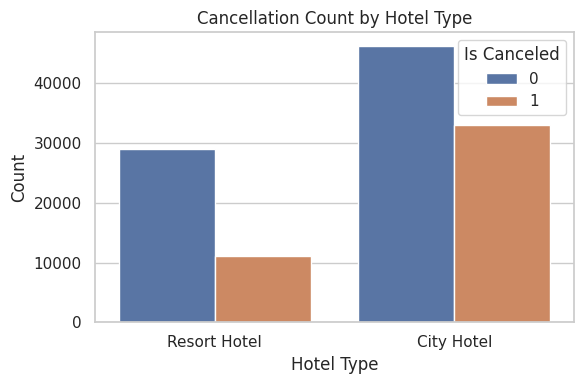

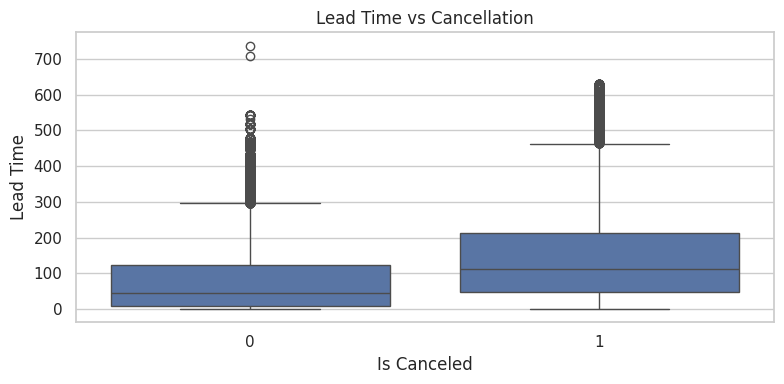

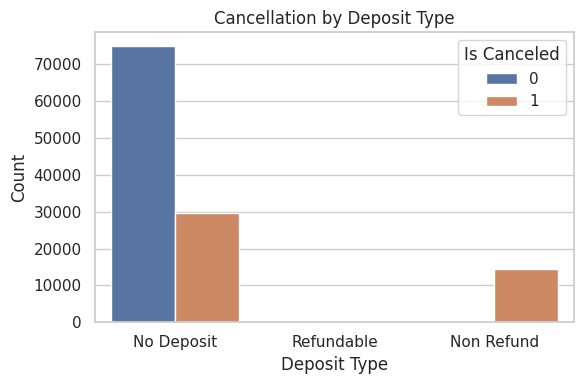

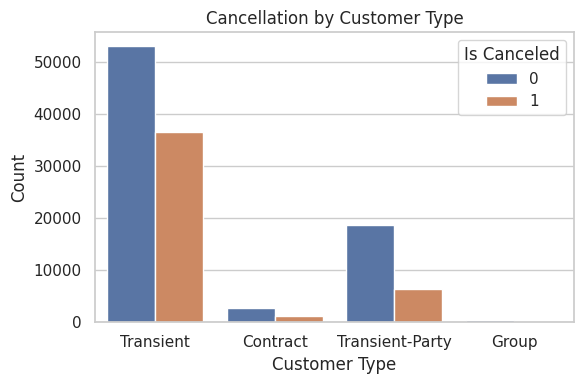

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plot style
sns.set(style="whitegrid")

# 1. Target Variable Distribution
target_plot = df['is_canceled'].value_counts(normalize=True)

# 2. Cancellation Rate by Hotel Type
plt.figure(figsize=(6, 4))
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title('Cancellation Count by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.legend(title='Is Canceled')
plt.tight_layout()

plt.show()

# 3. Lead Time vs Cancellation (Boxplot)
plt.figure(figsize=(8, 4))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time vs Cancellation')
plt.xlabel('Is Canceled')
plt.ylabel('Lead Time')
plt.tight_layout()
plt.show()

# 4. Cancellation Rate by Deposit Type
plt.figure(figsize=(6, 4))
sns.countplot(x='deposit_type', hue='is_canceled', data=df)
plt.title('Cancellation by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Count')
plt.legend(title='Is Canceled')
plt.tight_layout()
plt.show()

# 5. Cancellation Rate by Customer Type
plt.figure(figsize=(6, 4))
sns.countplot(x='customer_type', hue='is_canceled', data=df)
plt.title('Cancellation by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.legend(title='Is Canceled')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: One-hot encode categorical variables (excluding datetime)
df_encoded = pd.get_dummies(df, drop_first=True)

# Step 2: Define features and target variable
X = df_encoded.drop(['is_canceled', 'reservation_status_date'], axis=1)
y = df_encoded['is_canceled']

# Step 3: Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Train Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 5: Predict on test set
y_pred = model.predict(X_test)

# Step 6: Evaluation
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, output_dict=False)

conf_matrix, class_report


(array([[14124,   783],
        [ 1679,  7292]]),
 '              precision    recall  f1-score   support\n\n           0       0.89      0.95      0.92     14907\n           1       0.90      0.81      0.86      8971\n\n    accuracy                           0.90     23878\n   macro avg       0.90      0.88      0.89     23878\nweighted avg       0.90      0.90      0.90     23878\n')

In [ ]:
# Save cleaned dataset
df.to_csv("cleaned_hotel_bookings.csv", index=False)

# Download the file
from google.colab import files
files.download("cleaned_hotel_bookings.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>